# ERA5-Land monthly downloader for India

This notebook downloads ERA5-Land monthly reanalysis data for India with a 1° buffer from the Copernicus Climate Data Store.

Each month is saved as a separate NetCDF file in Google Drive for later use in the methane analysis workflow.


## Step 1. Install libraries

Install the packages required for CDS download, NetCDF reading, mapping, and data handling.


In [ ]:
# Install CDS API client and other dependencies
!pip install cdsapi netCDF4 xarray cartopy matplotlib numpy tqdm --quiet
print("✅ All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.1 MB/s eta 0:00:00
✅ All libraries installed successfully!


## Step 2. Configure CDS API

Enter the CDS API credentials needed to request ERA5-Land data.


In [ ]:
import os

# ── ✏️  ENTER YOUR CDS CREDENTIALS HERE ──────────────────────────────────────
CDS_URL     = "https://cds.climate.copernicus.eu/api"
CDS_API_KEY = "dbee6c15-baeb-4e8a-8928-f2554065a001"   # e.g. "xxxxxxxx-xxxx-xxxx-xxxx-xxxxxxxxxxxx"
# ─────────────────────────────────────────────────────────────────────────────

# Write credentials to ~/.cdsapirc
cdsapirc_content = f"""url: {CDS_URL}
key: {CDS_API_KEY}
"""

with open(os.path.expanduser("~/.cdsapirc"), "w") as f:
    f.write(cdsapirc_content)

print("✅ CDS API credentials configured at ~/.cdsapirc")

✅ CDS API credentials configured at ~/.cdsapirc


## Step 3. Mount Google Drive

Mount Drive so downloaded files can be saved permanently.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Define Drive output folder
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/ERA5_India_Data"
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
print(f"✅ Google Drive mounted. Output folder: {DRIVE_OUTPUT_DIR}")

Mounted at /content/drive
✅ Google Drive mounted. Output folder: /content/drive/MyDrive/ERA5_India_Data


## Step 4. Download ERA5-Land monthly files

Download one NetCDF file per month. Existing files are skipped so the workflow can resume after interruptions.


In [ ]:
import cdsapi
import shutil
from pathlib import Path
from tqdm import tqdm
import time

# ── Download Configuration ────────────────────────────────────────────────────
LOCAL_DIR = Path("/content/era5_data")
LOCAL_DIR.mkdir(parents=True, exist_ok=True)

# ── Geographical Extent ───────────────────────────────────────────────────────
# India bounding box: approx 8°N–37°N, 68°E–97°E  (+1° buffer on all sides)
AREA = [38, 67, 7, 98]   # [North, West, South, East]

# ── Years & Months ────────────────────────────────────────────────────────────
YEARS  = [str(y) for y in range(2014, 2026)]   # 2014–2025
MONTHS = [f"{m:02d}" for m in range(1, 13)]    # 01–12

# ── Variables ─────────────────────────────────────────────────────────────────
VARIABLES = [
    "2m_temperature",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "total_precipitation",
    "leaf_area_index_low_vegetation",
    "leaf_area_index_high_vegetation",
    "volumetric_soil_water_layer_1",
]

print("📋 Download Configuration")
print(f"   Dataset  : reanalysis-era5-land-monthly-means")
print(f"   Variables: {len(VARIABLES)} variables")
for v in VARIABLES:
    print(f"              • {v}")
print(f"   Period   : Jan 2014 – Dec 2025  ({len(YEARS) * len(MONTHS)} months)")
print(f"   Area     : N={AREA[0]}°, W={AREA[1]}°, S={AREA[2]}°, E={AREA[3]}°")
print(f"   Output   : {LOCAL_DIR}/<year>/<era5_land_india_YYYY_MM.nc>")
print()

# ── CDS Client ────────────────────────────────────────────────────────────────
client = cdsapi.Client()

# ── Helper: build output path ─────────────────────────────────────────────────
def monthly_path(year: str, month: str) -> Path:
    """Return local path for a single month file; create year sub-directory."""
    year_dir = LOCAL_DIR / year
    year_dir.mkdir(exist_ok=True)
    return year_dir / f"era5_land_india_{year}_{month}.nc"

# ── Download loop ─────────────────────────────────────────────────────────────
total = len(YEARS) * len(MONTHS)
done  = 0
skipped = 0
failed_months = []

outer_bar = tqdm(YEARS, desc="Years", position=0, leave=True)

for year in outer_bar:
    inner_bar = tqdm(MONTHS, desc=f"  {year}", position=1, leave=False)

    for month in inner_bar:
        local_path = monthly_path(year, month)

        # ── Skip if already downloaded ────────────────────────────────────────
        if local_path.exists() and local_path.stat().st_size > 10_000:
            inner_bar.set_postfix(status="⏭ skip")
            skipped += 1
            done += 1
            continue

        inner_bar.set_postfix(status="⏳ queued")

        request = {
            "product_type"   : ["monthly_averaged_reanalysis"],
            "variable"       : VARIABLES,
            "year"           : [year],
            "month"          : [month],
            "time"           : ["00:00"],
            "data_format"    : "netcdf",
            "download_format": "unarchived",
            "area"           : AREA,
        }

        try:
            client.retrieve(
                "reanalysis-era5-land-monthly-means",
                request,
                str(local_path),
            )
            inner_bar.set_postfix(status=f"✅ {local_path.stat().st_size/1e6:.1f} MB")
        except Exception as e:
            inner_bar.set_postfix(status="❌ failed")
            failed_months.append(f"{year}-{month}")
            print(f"\n⚠️  Failed: {year}-{month} → {e}")
            if local_path.exists():
                local_path.unlink()   # remove partial file

        done += 1

    outer_bar.set_postfix(done=done, skipped=skipped, failed=len(failed_months))

print("\n" + "═" * 60)
print(f"  Download loop complete")
print("═" * 60)
print(f"  Total months : {total}")
print(f"  Skipped      : {skipped}  (already present)")
print(f"  Failed       : {len(failed_months)}")
if failed_months:
    print(f"  Failed list  : {', '.join(failed_months)}")
print()

📋 Download Configuration
   Dataset  : reanalysis-era5-land-monthly-means
   Variables: 7 variables
              • 2m_temperature
              • 10m_u_component_of_wind
              • 10m_v_component_of_wind
              • total_precipitation
              • leaf_area_index_low_vegetation
              • leaf_area_index_high_vegetation
              • volumetric_soil_water_layer_1
   Period   : Jan 2014 – Dec 2025  (144 months)
   Area     : N=38°, W=67°, S=7°, E=98°
   Output   : /content/era5_data/<year>/<era5_land_india_YYYY_MM.nc>



  2014:   0%|          | 0/12 [00:00<?, ?it/s, status=⏳ queued]2026-04-19 07:41:28,664 INFO Request ID is 7a6232be-6b99-4ac0-b3dd-750d5f0b37af
INFO:ecmwf.datastores.legacy_client:Request ID is 7a6232be-6b99-4ac0-b3dd-750d5f0b37af
2026-04-19 07:41:28,826 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-04-19 07:41:42,879 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-04-19 07:41:50,616 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


df60f5e30d6253713101e08f6637ed43.nc:   0%|          | 0.00/954k [00:00<?, ?B/s]


  2014:   8%|▊         | 1/12 [00:24<04:27, 24.31s/it, status=⏳ queued]2026-04-19 07:41:52,970 INFO Request ID is dca4d588-df9d-425e-bfa6-723b3a2c9f05
INFO:ecmwf.datastores.legacy_client:Request ID is dca4d588-df9d-425e-bfa6-723b3a2c9f05
2026-04-19 07:41:53,116 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-04-19 07:42:01,851 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-04-19 07:42:14,811 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


a734163a58662ae22234f3eeba34a2df.nc:   0%|          | 0.00/948k [00:00<?, ?B/s]

...

1bcdc74727b815b4926399ab565f8f45.nc:   0%|          | 0.00/941k [00:00<?, ?B/s]


  2025:  92%|█████████▏| 11/12 [04:42<00:24, 24.20s/it, status=⏳ queued]2026-04-19 08:58:01,156 INFO Request ID is d3ee7f48-28b0-47de-b283-9b8e819ae350
INFO:ecmwf.datastores.legacy_client:Request ID is d3ee7f48-28b0-47de-b283-9b8e819ae350
2026-04-19 08:58:01,309 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-04-19 08:58:15,230 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-04-19 08:58:34,785 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


18d44b3274340dd0d33e35afc8d3cadd.nc:   0%|          | 0.00/941k [00:00<?, ?B/s]


Years: 100%|██████████| 12/12 [1:17:08<00:00, 385.70s/it, done=144, failed=0, skipped=0]


════════════════════════════════════════════════════════════
  Download loop complete
════════════════════════════════════════════════════════════
  Total months : 144
  Skipped      : 0  (already present)
  Failed       : 0



## Step 5. Sync files to Google Drive

Copy the downloaded monthly files to the selected Drive folder.


In [ ]:
import glob

print("📂 Syncing all monthly files to Google Drive...")

nc_files = sorted(LOCAL_DIR.rglob("era5_land_india_*.nc"))
copied = 0

for src in tqdm(nc_files, desc="Copying"):
    # Mirror the year sub-directory structure on Drive
    rel      = src.relative_to(LOCAL_DIR)          # e.g.  2019/era5_land_india_2019_06.nc
    dst_dir  = Path(DRIVE_OUTPUT_DIR) / rel.parent
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / src.name

    if not dst.exists() or dst.stat().st_size != src.stat().st_size:
        shutil.copy2(str(src), str(dst))
        copied += 1

print(f"\n✅ Sync complete — {copied} new/updated file(s) copied to Google Drive.")
print(f"   Drive folder: {DRIVE_OUTPUT_DIR}")

📂 Syncing all monthly files to Google Drive...


Copying: 100%|██████████| 144/144 [00:02<00:00, 49.10it/s]


✅ Sync complete — 144 new/updated file(s) copied to Google Drive.
   Drive folder: /content/drive/MyDrive/ERA5_India_Data


## Step 6. Inspect one monthly file

Open one downloaded file and check its variables, coordinates, and time information.


In [ ]:
import xarray as xr
import numpy as np

# ── Pick any downloaded month to inspect ─────────────────────────────────────
INSPECT_YEAR  = "2019"
INSPECT_MONTH = "06"

inspect_path = monthly_path(INSPECT_YEAR, INSPECT_MONTH)
print(f"Opening: {inspect_path}\n")

ds = xr.open_dataset(str(inspect_path))

print("═" * 60)
print("  ERA5-Land Dataset Summary")
print("═" * 60)
print(ds)
print()
print("── Dimensions ──")
for dim, size in ds.dims.items():
    print(f"   {dim}: {size}")
print()
print("── Variables ──")
for var in ds.data_vars:
    v = ds[var]
    units     = v.attrs.get("units", "N/A")
    long_name = v.attrs.get("long_name", "N/A")
    print(f"   {var:10s}: shape={v.shape},  units={units},  {long_name}")
print()
print("── Spatial extent ──")
print(f"   Lat : {float(ds.latitude.min()):.2f}° to {float(ds.latitude.max()):.2f}°")
print(f"   Lon : {float(ds.longitude.min()):.2f}° to {float(ds.longitude.max()):.2f}°")

Opening: /content/era5_data/2019/era5_land_india_2019_06.nc

════════════════════════════════════════════════════════════
  ERA5-Land Dataset Summary
════════════════════════════════════════════════════════════
<xarray.Dataset> Size: 3MB
Dimensions:     (valid_time: 1, latitude: 311, longitude: 311)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2019-06-01
  * latitude    (latitude) float64 2kB 38.0 37.9 37.8 37.7 ... 7.3 7.2 7.1 7.0
  * longitude   (longitude) float64 2kB 67.0 67.1 67.2 67.3 ... 97.8 97.9 98.0
    number      int64 8B ...
    expver      <U4 16B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 387kB ...
    u10         (valid_time, latitude, longitude) float32 387kB ...
    v10         (valid_time, latitude, longitude) float32 387kB ...
    tp          (valid_time, latitude, longitude) float32 387kB ...
    lai_lv      (valid_time, latitude, longitude) float32 387kB ...
    lai_hv      (valid_time, latitude, longitude) float32

/tmp/ipykernel_6442/2827888425.py:19: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for dim, size in ds.dims.items():
<frozen _collections_abc>:894: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.


## Step 7. Visual checks

Plot selected variables for one month to confirm that the downloaded data are readable and spatially correct.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings("ignore")

# ── Load sample month ─────────────────────────────────────────────────────────
SAMPLE_YEAR  = "2019"
SAMPLE_MONTH = "06"
SAMPLE_LABEL = f"{SAMPLE_YEAR}-{SAMPLE_MONTH}"

ds_sample = xr.open_dataset(str(monthly_path(SAMPLE_YEAR, SAMPLE_MONTH)))
lats = ds_sample.latitude.values
lons = ds_sample.longitude.values

def base_map_ax(fig, pos, title):
    """Create a base Cartopy map axis."""
    ax = fig.add_subplot(pos, projection=ccrs.PlateCarree())
    ax.set_extent([67, 98, 7, 38], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"),   linewidth=0.6, linestyle=":")
    ax.add_feature(cfeature.STATES.with_scale("50m"),    linewidth=0.3, edgecolor="grey")
    ax.add_feature(cfeature.LAND.with_scale("50m"),      facecolor="#f5f5f0")
    ax.add_feature(cfeature.OCEAN.with_scale("50m"),     facecolor="#d0e8f0")
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="grey", alpha=0.5, linestyle="--")
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(range(67, 99, 5))
    gl.ylocator = mticker.FixedLocator(range(7, 39, 5))
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    return ax

print(f"🗺️  Generating visualizations for {SAMPLE_LABEL} ...")

🗺️  Generating visualizations for 2019-06 ...


### 7a. 2 m temperature

Map near-surface air temperature for the selected month.


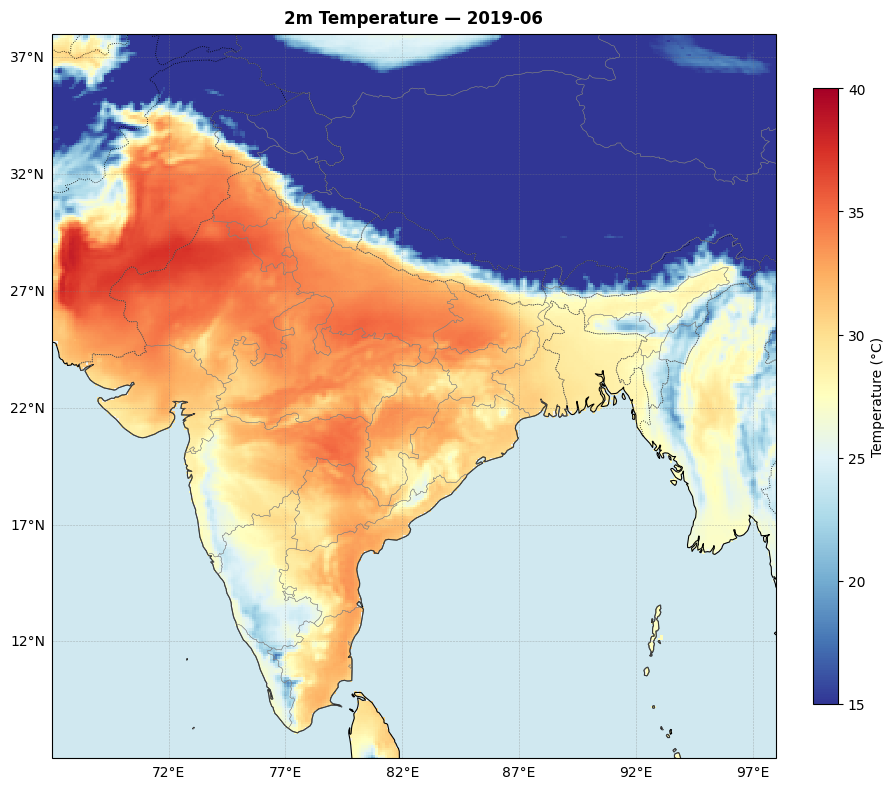

💾 Saved: /content/era5_data/plot_t2m.png


In [ ]:
fig = plt.figure(figsize=(10, 8))
ax  = base_map_ax(fig, 111, f"2m Temperature — {SAMPLE_LABEL}")

t2m = ds_sample["t2m"].values.squeeze() - 273.15   # K → °C

im = ax.pcolormesh(lons, lats, t2m, transform=ccrs.PlateCarree(),
                   cmap="RdYlBu_r", vmin=15, vmax=40, shading="auto")
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.04, shrink=0.85, aspect=25)
cbar.set_label("Temperature (°C)", fontsize=10)
plt.tight_layout()
out = LOCAL_DIR / "plot_t2m.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
shutil.copy2(str(out), os.path.join(DRIVE_OUTPUT_DIR, "plot_t2m.png"))
plt.show()
print(f"💾 Saved: {out}")

### 7b. 10 m u-wind

Map the east-west wind component.


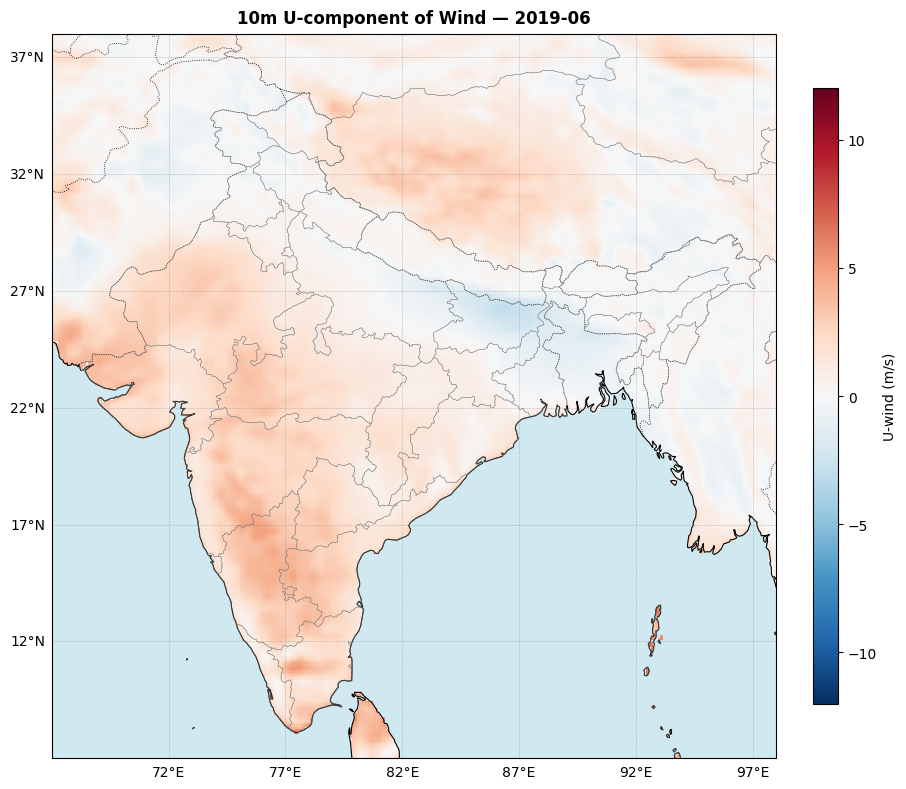

💾 Saved: /content/era5_data/plot_u10.png


In [ ]:
fig = plt.figure(figsize=(10, 8))
ax  = base_map_ax(fig, 111, f"10m U-component of Wind — {SAMPLE_LABEL}")

u10 = ds_sample["u10"].values.squeeze()

im = ax.pcolormesh(lons, lats, u10, transform=ccrs.PlateCarree(),
                   cmap="RdBu_r", vmin=-12, vmax=12, shading="auto")
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.04, shrink=0.85, aspect=25)
cbar.set_label("U-wind (m/s)", fontsize=10)
plt.tight_layout()
out = LOCAL_DIR / "plot_u10.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
shutil.copy2(str(out), os.path.join(DRIVE_OUTPUT_DIR, "plot_u10.png"))
plt.show()
print(f"💾 Saved: {out}")

### 7c. 10 m v-wind

Map the north-south wind component.


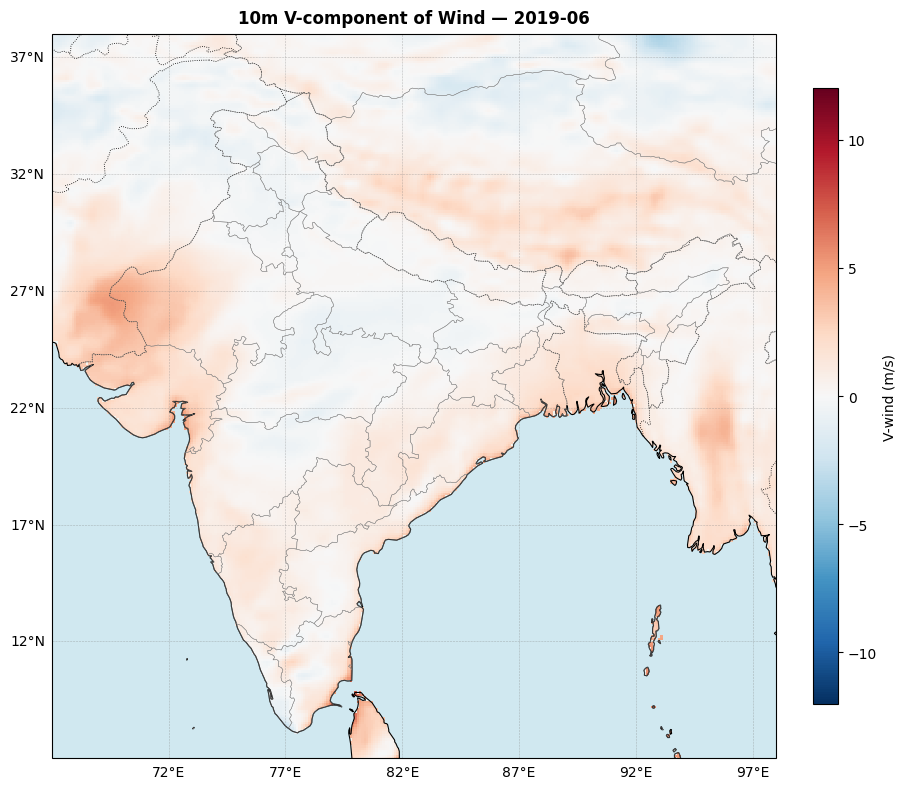

💾 Saved: /content/era5_data/plot_v10.png


In [ ]:
fig = plt.figure(figsize=(10, 8))
ax  = base_map_ax(fig, 111, f"10m V-component of Wind — {SAMPLE_LABEL}")

v10 = ds_sample["v10"].values.squeeze()

im = ax.pcolormesh(lons, lats, v10, transform=ccrs.PlateCarree(),
                   cmap="RdBu_r", vmin=-12, vmax=12, shading="auto")
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.04, shrink=0.85, aspect=25)
cbar.set_label("V-wind (m/s)", fontsize=10)
plt.tight_layout()
out = LOCAL_DIR / "plot_v10.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
shutil.copy2(str(out), os.path.join(DRIVE_OUTPUT_DIR, "plot_v10.png"))
plt.show()
print(f"💾 Saved: {out}")

### 7d. Total precipitation

Map monthly total precipitation.


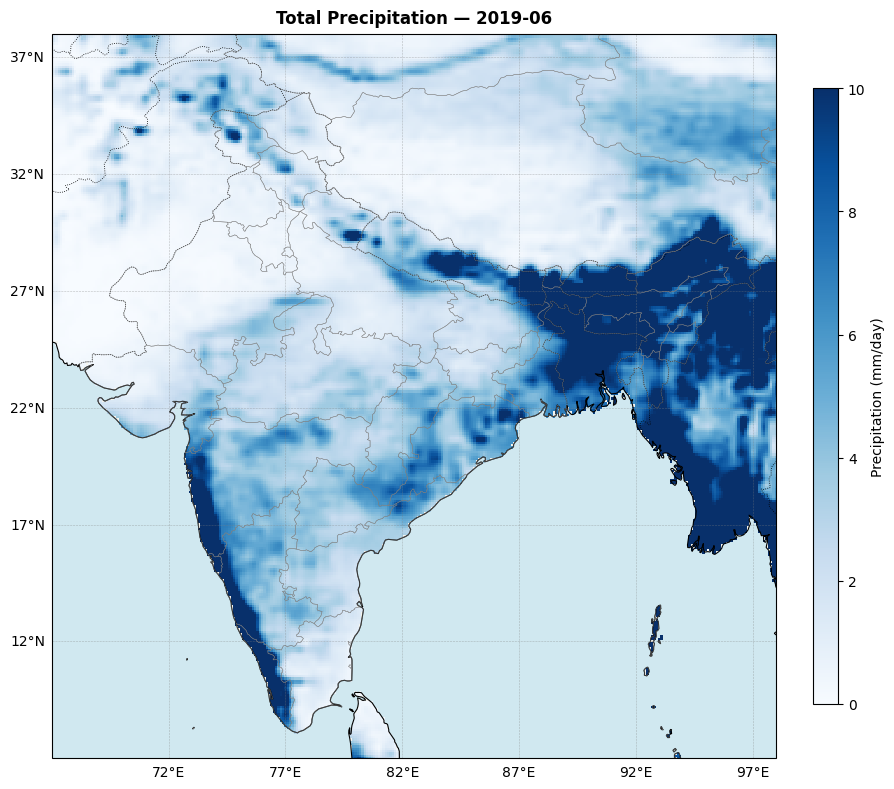

💾 Saved: /content/era5_data/plot_tp.png


In [ ]:
fig = plt.figure(figsize=(10, 8))
ax  = base_map_ax(fig, 111, f"Total Precipitation — {SAMPLE_LABEL}")

tp = ds_sample["tp"].values.squeeze() * 1000   # m/day → mm/day

im = ax.pcolormesh(lons, lats, tp, transform=ccrs.PlateCarree(),
                   cmap="Blues", vmin=0, vmax=10, shading="auto")
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.04, shrink=0.85, aspect=25)
cbar.set_label("Precipitation (mm/day)", fontsize=10)
plt.tight_layout()
out = LOCAL_DIR / "plot_tp.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
shutil.copy2(str(out), os.path.join(DRIVE_OUTPUT_DIR, "plot_tp.png"))
plt.show()
print(f"💾 Saved: {out}")

### 7e. Low-vegetation leaf area index

Map leaf area index for low vegetation.


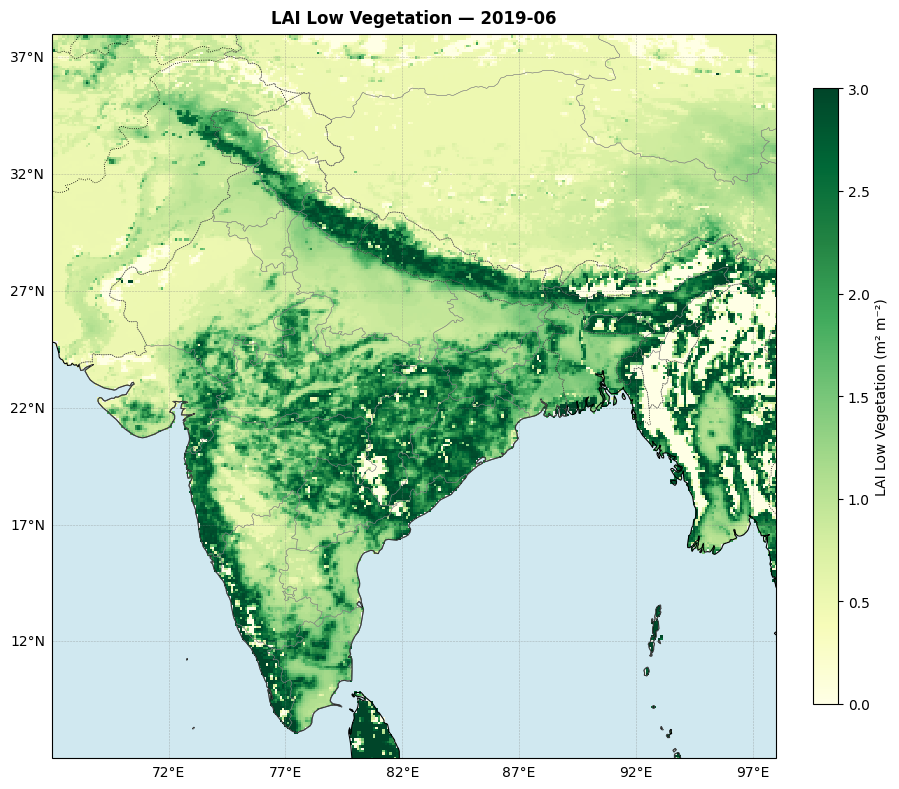

💾 Saved: /content/era5_data/plot_lai_lv.png


In [ ]:
fig = plt.figure(figsize=(10, 8))
ax  = base_map_ax(fig, 111, f"LAI Low Vegetation — {SAMPLE_LABEL}")

lai_lv = ds_sample["lai_lv"].values.squeeze()

im = ax.pcolormesh(lons, lats, lai_lv, transform=ccrs.PlateCarree(),
                   cmap="YlGn", vmin=0, vmax=3, shading="auto")
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.04, shrink=0.85, aspect=25)
cbar.set_label("LAI Low Vegetation (m² m⁻²)", fontsize=10)
plt.tight_layout()
out = LOCAL_DIR / "plot_lai_lv.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
shutil.copy2(str(out), os.path.join(DRIVE_OUTPUT_DIR, "plot_lai_lv.png"))
plt.show()
print(f"💾 Saved: {out}")

### 7f. High-vegetation leaf area index

Map leaf area index for high vegetation.


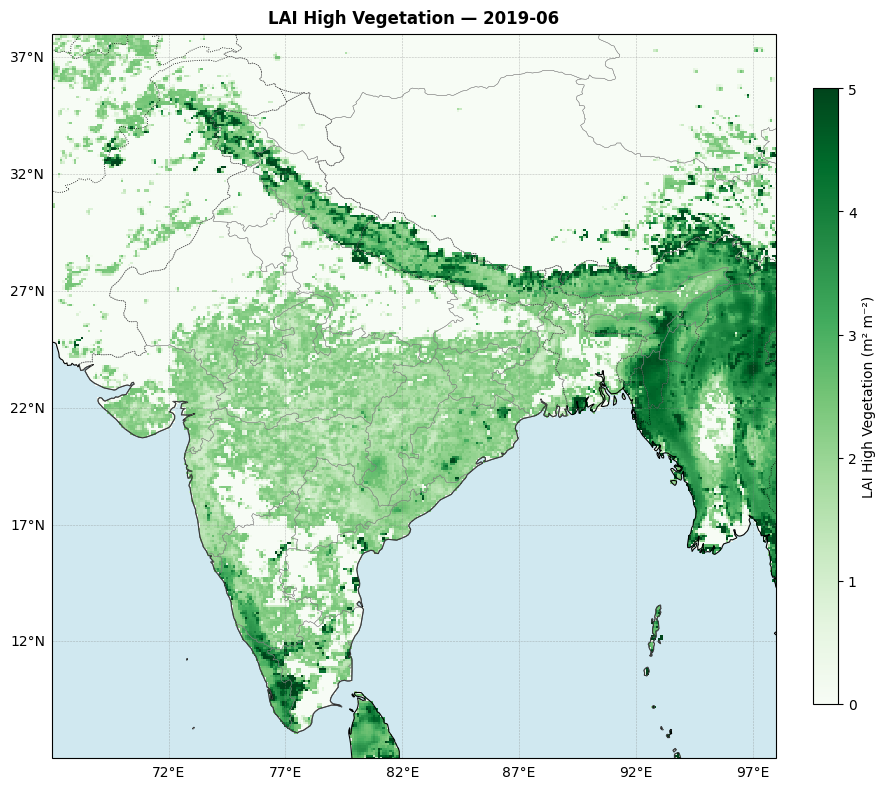

💾 Saved: /content/era5_data/plot_lai_hv.png


In [ ]:
fig = plt.figure(figsize=(10, 8))
ax  = base_map_ax(fig, 111, f"LAI High Vegetation — {SAMPLE_LABEL}")

lai_hv = ds_sample["lai_hv"].values.squeeze()

im = ax.pcolormesh(lons, lats, lai_hv, transform=ccrs.PlateCarree(),
                   cmap="Greens", vmin=0, vmax=5, shading="auto")
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.04, shrink=0.85, aspect=25)
cbar.set_label("LAI High Vegetation (m² m⁻²)", fontsize=10)
plt.tight_layout()
out = LOCAL_DIR / "plot_lai_hv.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
shutil.copy2(str(out), os.path.join(DRIVE_OUTPUT_DIR, "plot_lai_hv.png"))
plt.show()
print(f"💾 Saved: {out}")

### 7g. Volumetric soil water

Map top-layer soil moisture.


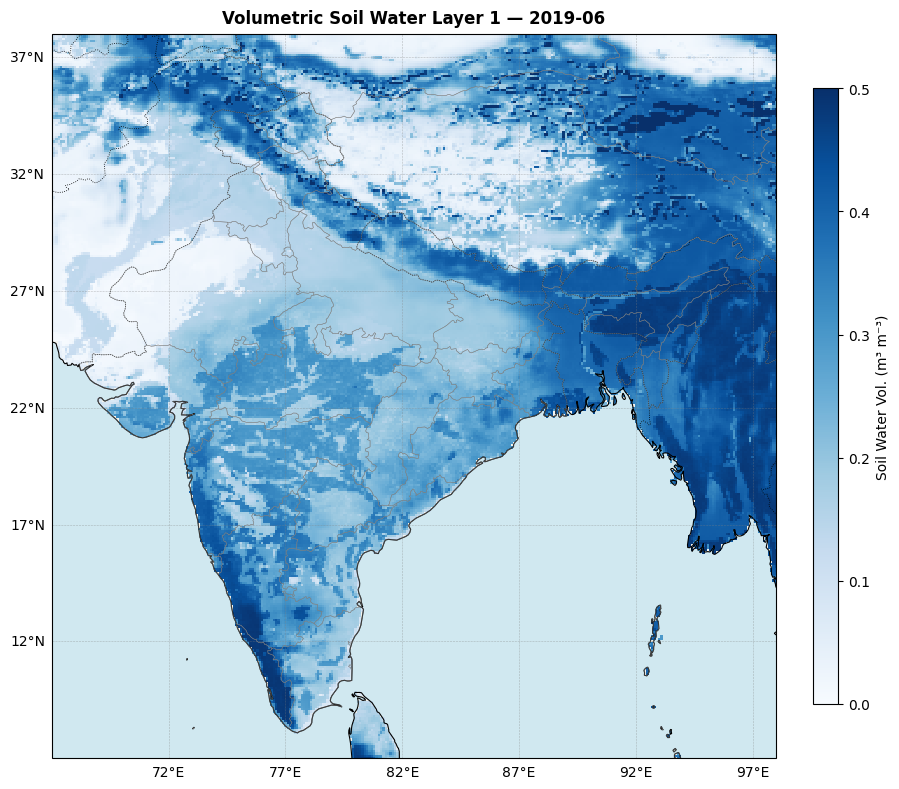

💾 Saved: /content/era5_data/plot_swvl1.png


In [ ]:
fig = plt.figure(figsize=(10, 8))
ax  = base_map_ax(fig, 111, f"Volumetric Soil Water Layer 1 — {SAMPLE_LABEL}")

swvl1 = ds_sample["swvl1"].values.squeeze()

im = ax.pcolormesh(lons, lats, swvl1, transform=ccrs.PlateCarree(),
                   cmap="Blues", vmin=0, vmax=0.5, shading="auto")
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.04, shrink=0.85, aspect=25)
cbar.set_label("Soil Water Vol. (m³ m⁻³)", fontsize=10)
plt.tight_layout()
out = LOCAL_DIR / "plot_swvl1.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
shutil.copy2(str(out), os.path.join(DRIVE_OUTPUT_DIR, "plot_swvl1.png"))
plt.show()
print(f"💾 Saved: {out}")

### 7h. Wind speed and direction

Calculate wind speed and show wind vectors for the selected month.


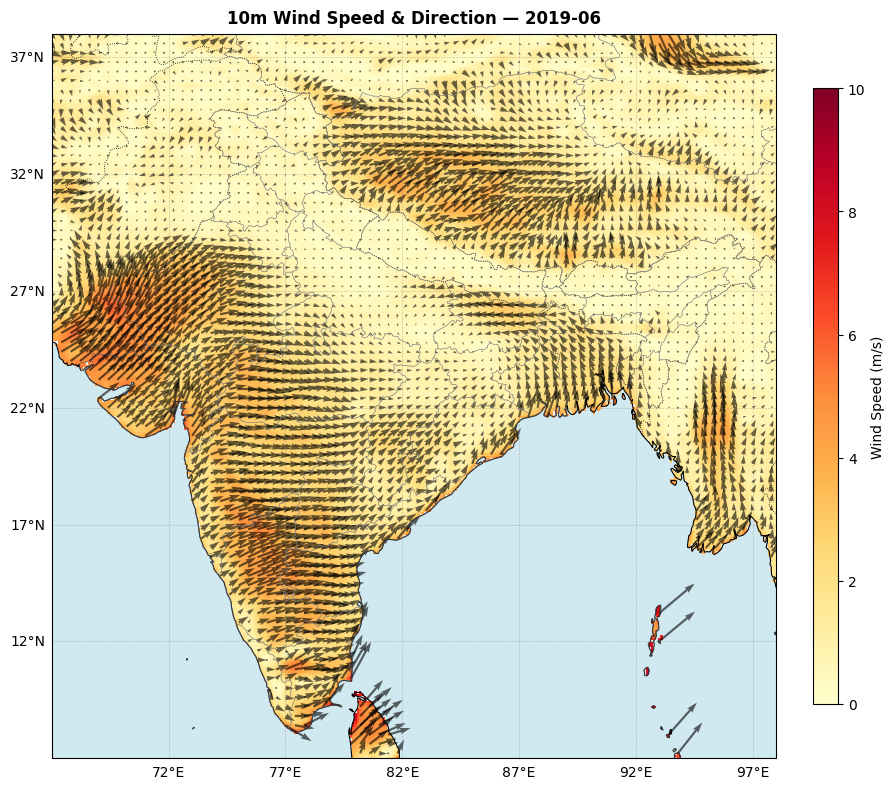

💾 Saved: /content/era5_data/plot_wind_speed.png


In [ ]:
fig = plt.figure(figsize=(10, 8))
ax  = base_map_ax(fig, 111, f"10m Wind Speed & Direction — {SAMPLE_LABEL}")

u10 = ds_sample["u10"].values.squeeze()
v10 = ds_sample["v10"].values.squeeze()
ws  = np.sqrt(u10**2 + v10**2)

im = ax.pcolormesh(lons, lats, ws, transform=ccrs.PlateCarree(),
                   cmap="YlOrRd", vmin=0, vmax=10, shading="auto")
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.04, shrink=0.85, aspect=25)
cbar.set_label("Wind Speed (m/s)", fontsize=10)

step = 4
lon2d, lat2d = np.meshgrid(lons[::step], lats[::step])
ax.quiver(lon2d, lat2d, u10[::step, ::step], v10[::step, ::step],
          transform=ccrs.PlateCarree(), scale=120, width=0.003, color="black", alpha=0.6)

plt.tight_layout()
out = LOCAL_DIR / "plot_wind_speed.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
shutil.copy2(str(out), os.path.join(DRIVE_OUTPUT_DIR, "plot_wind_speed.png"))
plt.show()
print(f"💾 Saved: {out}")

## Step 8. Summary

Summarise the downloaded files and variables available for later analysis.


In [ ]:
import glob

all_nc = sorted(LOCAL_DIR.rglob("era5_land_india_*.nc"))
total_size_mb = sum(f.stat().st_size for f in all_nc) / 1e6

print("═" * 60)
print("  ✅  All tasks complete!")
print("═" * 60)
print(f"\n📁 Monthly NetCDF files in {LOCAL_DIR}:")
print(f"   Count : {len(all_nc)}")
print(f"   Total : {total_size_mb:.1f} MB")
print()
print("📌 Variable name mapping (xarray short name → ERA5 CDS name):")
print("   t2m    → 2m_temperature                   (K;   −273.15 for °C)")
print("   u10    → 10m_u_component_of_wind           (m/s; +ve = westerly)")
print("   v10    → 10m_v_component_of_wind           (m/s; +ve = southerly)")
print("   tp     → total_precipitation               (m/day; ×1000 for mm/day)")
print("   lai_lv → leaf_area_index_low_vegetation    (m² m⁻²)")
print("   lai_hv → leaf_area_index_high_vegetation   (m² m⁻²)")
print("   swvl1  → volumetric_soil_water_layer_1     (m³ m⁻³)")
print()
print("📁 Drive folder:", DRIVE_OUTPUT_DIR)

════════════════════════════════════════════════════════════
  ✅  All tasks complete!
════════════════════════════════════════════════════════════

📁 Monthly NetCDF files in /content/era5_data:
   Count : 144
   Total : 140.1 MB

📌 Variable name mapping (xarray short name → ERA5 CDS name):
   t2m    → 2m_temperature                   (K;   −273.15 for °C)
   u10    → 10m_u_component_of_wind           (m/s; +ve = westerly)
   v10    → 10m_v_component_of_wind           (m/s; +ve = southerly)
   tp     → total_precipitation               (m/day; ×1000 for mm/day)
   lai_lv → leaf_area_index_low_vegetation    (m² m⁻²)
   lai_hv → leaf_area_index_high_vegetation   (m² m⁻²)
   swvl1  → volumetric_soil_water_layer_1     (m³ m⁻³)

📁 Drive folder: /content/drive/MyDrive/ERA5_India_Data
